# Ejercicio Deber Análisis de datos clínicos para la detección de enfermedades cardíacas
![Logo](img/ITQ.png)
## Nombre: Gabriel Q. Pazmiño
### Fecha: 06/05/2026
<h1>github</h1>
** https://github.com/Vanship77/cuadernoIA2026.git **


# Práctica Académica
## Normalización y Estandarización de Datos en Inteligencia Artificial
# Análisis y aplicación de técnicas de normalización y estandarización en conjunto de datos para modelos de aprendizaje automático
### Enunciado
En la actualidad, las enfermedades cardiovasculares representan una de las principales causas de mortalidad a nivel mundial, lo que ha impulsado el uso de técnicas de análisis de datos e inteligencia artificial para apoyar en su detección temprana.<br>

Un centro médico especializado ha recopilado un conjunto de datos clínicos de pacientes, el cual incluye variables como edad, presión arterial, niveles de colesterol, frecuencia cardíaca máxima y otros indicadores relevantes para la salud cardiovascular. Sin embargo, durante el análisis preliminar, se ha identificado que los datos presentan diferencias significativas en sus escalas y rangos, lo que podría afectar negativamente el desempeño de los modelos predictivos.<br>

Como parte del equipo de analistas de datos, se le ha asignado la tarea de realizar un proceso de preprocesamiento de los datos, específicamente aplicando técnicas de normalización y estandarización, con el objetivo de preparar la información para su uso en modelos de aprendizaje automático orientados a la clasificación de pacientes con riesgo de enfermedad cardíaca.<br>
El propósito de esta actividad es comprender cómo las diferencias en la escala de los datos pueden influir en los resultados y cómo las técnicas de escalado permiten mejorar la calidad del análisis y la precisión de los modelos.<br>
### Objetivo General
Aplicar técnicas de normalización y estandarización a un conjunto de datos clínicos relacionados con enfermedades cardíacas, con el fin de analizar su impacto en la preparación de datos y en el rendimiento de modelos de aprendizaje automático.<br>
### Objetivos especificos
* Identificar diferencias de escala entre variables numércias.
* Aplicar técnicas de normalización (Min-Max)
* Aplicar técnicas de estandarización (Z-score)
* Analizar la importancia del preprocesaminto en modelos de IA
### Antecedentes /Fundamentación teórica
En el contexto del aprendizaje automático, los algoritmos suelen verse afectados por la escala de los datos. Variables con valores grandes pueden dominar el comportamiento del modelo, generando sesgos y resultados pocos conficables.<br>
Para mitigar este problema, se emplea técnicas como:
* **Normalización**: transforma los datos a un rango especifico (generalmente[0,1])
* **Estandarización**: ajusta los datos para que tengan mdia 0 y desviación estandar 1.
Estas técnicas son fundamentales en algoritmos como:
* KNN
* Regresión logística
* Redes neuronales
### Resultado esperado
El estudiante será capaz de reconocer la importancia del escalado de datos en contextos reales de salud, comprendiendo que un adecuado preprocesamiento es fundamental para el desarrollo de modelos predictivos confiables en inteligencia artificial.
## Conjunto de datos  utilizar
DataSet 1: <a href="https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset">Conjunto de datos de enfermedades cardiacas</a>

In [1]:
# Importamos las librerias de sklearn para este caso
import pandas as pd
import numpy as np
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Configuramos el ambiente para descarga del archivo en Kaggle
import os
os.environ['KAGGLE_CONFIG_DIR'] = "C:/Users/NW/OneDrive/Escritorio/DBRS/INTELIGENCIA ARTIFICIAL/FUNDAMENTOS DE MACHINE LEARNING/cuadernoIA2026/.kaggle"

In [3]:
# Crear carpeta para dataset
os.makedirs("dataset_heart", exist_ok=True)

In [4]:
# Descargar dataset de enfermedades cardíacas
!kaggle datasets download -d johnsmith88/heart-disease-dataset

"kaggle" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [5]:
# Descomprimir archivo
with zipfile.ZipFile("heart-disease-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_heart")

In [6]:
# Cargar el dataset
df = pd.read_csv("dataset_heart/heart.csv")

In [7]:
# Mostrar primeras filas
print("=== PRIMERAS FILAS DEL DATASET ===")
df.head()

=== PRIMERAS FILAS DEL DATASET ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
# Mostramos la información general del dataset
print("\n=== INFORMACIÓN DEL DATASET ===")
df.info()

# Verificamos si existen valores nulos en cada columna
print("\n=== VERIFICACIÓN DE VALORES NULOS ===")
print(df.isnull().sum())

# Mostramos las estadísticas descriptivas de los datos numéricos
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

# Analizamos la distribución de la variable objetivo (target)
print("\n=== DISTRIBUCIÓN DE ENFERMEDAD CARDÍACA ===")
print(df['target'].value_counts())

# Calculamos el porcentaje de personas con enfermedad cardíaca
print(f"Porcentaje con enfermedad: {df['target'].mean()*100:.2f}%")


=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

=== VERIFICACIÓN DE VALORES NULOS ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slop

In [9]:
# Separar variables numéricas (excluyendo la target)
X = df.drop('target', axis=1)
y = df['target']

In [10]:
# Mostramos los rangos de cada variable
print("\n=== RANGOS DE VARIABLES NUMÉRICAS ===")
for col in X.columns:
    print(f"{col:20s} | min: {X[col].min():8.2f} | max: {X[col].max():8.2f} | rango: {X[col].max()-X[col].min():8.2f}")


=== RANGOS DE VARIABLES NUMÉRICAS ===
age                  | min:    29.00 | max:    77.00 | rango:    48.00
sex                  | min:     0.00 | max:     1.00 | rango:     1.00
cp                   | min:     0.00 | max:     3.00 | rango:     3.00
trestbps             | min:    94.00 | max:   200.00 | rango:   106.00
chol                 | min:   126.00 | max:   564.00 | rango:   438.00
fbs                  | min:     0.00 | max:     1.00 | rango:     1.00
restecg              | min:     0.00 | max:     2.00 | rango:     2.00
thalach              | min:    71.00 | max:   202.00 | rango:   131.00
exang                | min:     0.00 | max:     1.00 | rango:     1.00
oldpeak              | min:     0.00 | max:     6.20 | rango:     6.20
slope                | min:     0.00 | max:     2.00 | rango:     2.00
ca                   | min:     0.00 | max:     4.00 | rango:     4.00
thal                 | min:     0.00 | max:     3.00 | rango:     3.00


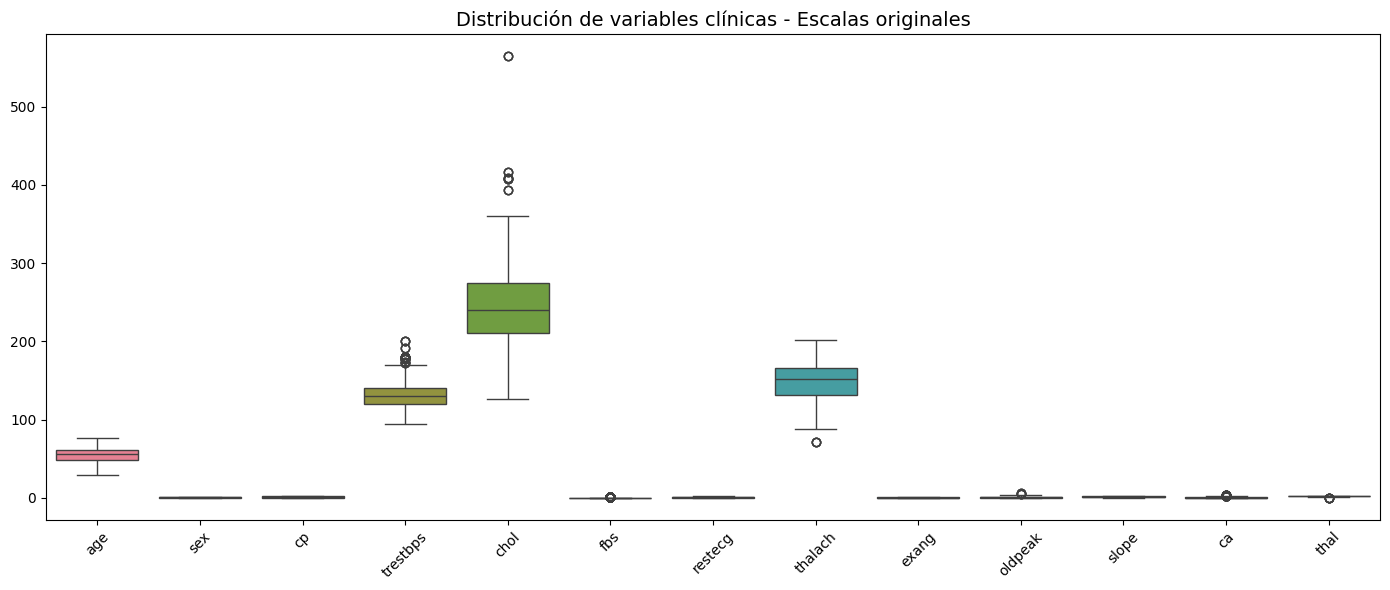

In [11]:
# Creamos una figura para visualizar los datos
plt.figure(figsize=(14, 6))

# Generamos un boxplot para observar la distribución
# de las variables clínicas en su escala original
sns.boxplot(data=X)

# Agregamos título al gráfico
plt.title("Distribución de variables clínicas - Escalas originales", fontsize=14)

# Rotamos los nombres de las variables para mejor visualización
plt.xticks(rotation=45)

# Ajustamos automáticamente los espacios del gráfico
plt.tight_layout()

# Mostramos el gráfico
plt.show()

In [12]:
# Aplicamos la normalización Min-Max:
# transforma los datos a una escala entre 0 y 1
# usando los valores mínimo y máximo de cada variable
normalizer = preprocessing.MinMaxScaler()

# Ajustamos y transformamos los datos
X_norm = normalizer.fit_transform(X)

# Convertimos el resultado nuevamente en DataFrame
X_norm = pd.DataFrame(X_norm, columns=X.columns)

# Mostramos estadísticas de los datos normalizados
print("\n=== DATOS NORMALIZADOS (Min-Max) ===")
print(X_norm.describe())


=== DATOS NORMALIZADOS (Min-Max) ===
               age          sex           cp     trestbps         chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.529878     0.695610     0.314146     0.354827     0.273973   
std       0.189006     0.460373     0.343214     0.165252     0.117791   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.395833     0.000000     0.000000     0.245283     0.194064   
50%       0.562500     1.000000     0.333333     0.339623     0.260274   
75%       0.666667     1.000000     0.666667     0.433962     0.340183   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.264878     0.596291     0.336585     0.172825   
std       0.356527     0.263939     0.175616     0.472772     0.189525   

In [13]:
# Aplicamos la estandarización Z-score:
# transforma los datos para que cada variable tenga:
# Media ≈ 0 y Desviación estándar ≈ 1
standardizer = preprocessing.StandardScaler()

# Ajustamos y transformamos los datos
X_std = standardizer.fit_transform(X)

# Convertimos el resultado nuevamente en DataFrame
X_std = pd.DataFrame(X_std, columns=X.columns)

# Mostramos estadísticas de los datos estandarizados
print("\n=== DATOS ESTANDARIZADOS (Z-score) ===")
print(X_std.describe())


=== DATOS ESTANDARIZADOS (Z-score) ===
                age           sex            cp      trestbps          chol  \
count  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03   
mean  -3.431402e-16  1.802352e-16  5.545699e-17 -7.036106e-16 -3.466062e-18   
std    1.000488e+00  1.000488e+00  1.000488e+00  1.000488e+00  1.000488e+00   
min   -2.804866e+00 -1.511706e+00 -9.157554e-01 -2.148237e+00 -2.327054e+00   
25%   -7.095548e-01 -1.511706e+00 -9.157554e-01 -6.632165e-01 -6.787242e-01   
50%    1.726817e-01  6.615041e-01  5.593123e-02 -9.205458e-02 -1.163527e-01   
75%    7.240794e-01  6.615041e-01  1.027618e+00  4.791073e-01  5.623715e-01   
max    2.488552e+00  6.615041e-01  1.999305e+00  3.906079e+00  6.166694e+00   

                fbs       restecg       thalach         exang       oldpeak  \
count  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03  1.025000e+03   
mean  -4.159275e-17 -8.318549e-17 -4.332578e-16 -7.625337e-17 -2.426243e-16   
std    1.00

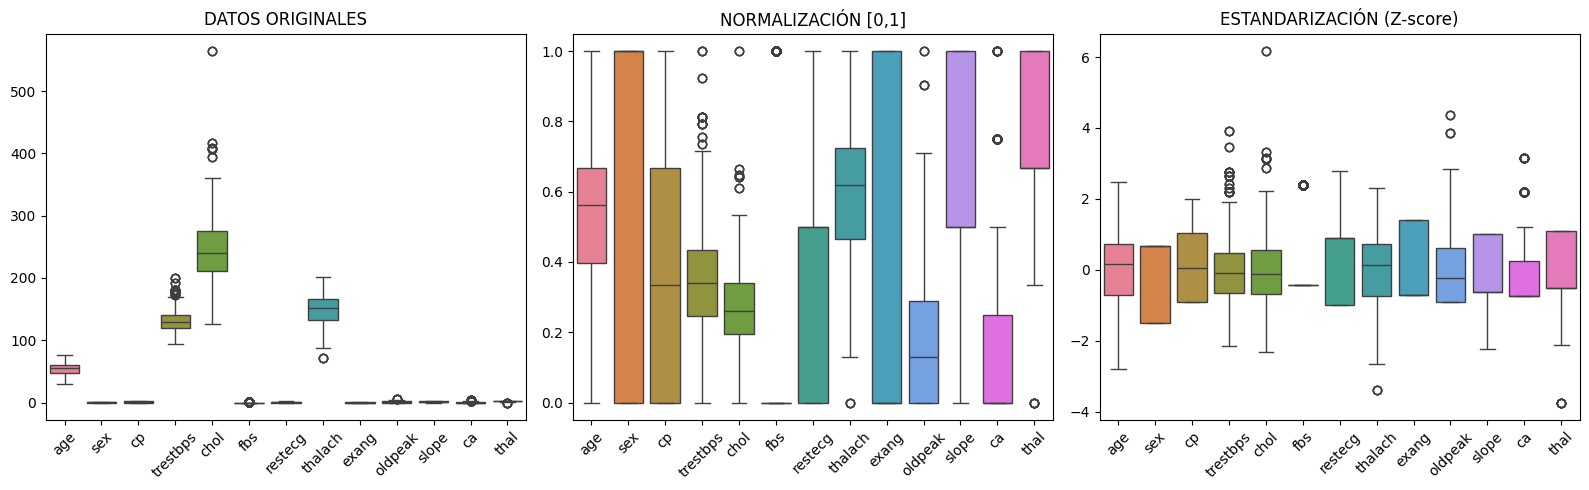

In [14]:
# Creamos una figura grande para comparar los tres conjuntos de datos
plt.figure(figsize=(16, 5))

# ---------------- DATOS ORIGINALES ----------------
# Primer gráfico: datos sin transformación
plt.subplot(1, 3, 1)
sns.boxplot(data=X)

# Título del gráfico
plt.title("DATOS ORIGINALES", fontsize=12)

# Rotamos etiquetas para mejor visualización
plt.xticks(rotation=45)

# ---------------- DATOS NORMALIZADOS ----------------
# Segundo gráfico: datos normalizados en rango [0,1]
plt.subplot(1, 3, 2)
sns.boxplot(data=X_norm)

# Título del gráfico
plt.title("NORMALIZACIÓN [0,1]", fontsize=12)

# Rotamos etiquetas
plt.xticks(rotation=45)

# ---------------- DATOS ESTANDARIZADOS ----------------
# Tercer gráfico: datos estandarizados con Z-score
plt.subplot(1, 3, 3)
sns.boxplot(data=X_std)

# Título del gráfico
plt.title("ESTANDARIZACIÓN (Z-score)", fontsize=12)

# Rotamos etiquetas
plt.xticks(rotation=45)

# Ajustamos automáticamente el espacio entre gráficos
plt.tight_layout()

# Mostramos la visualización completa
plt.show()

In [15]:
# Dividimos los datos en conjuntos de entrenamiento y prueba
# 70% para entrenamiento y 30% para prueba
# stratify=y mantiene la proporción de clases de la variable objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ---------------- NORMALIZACIÓN ----------------
# Aplicamos normalización Min-Max a los datos
# Escala los valores en un rango entre [0,1]

# Ajustamos y transformamos los datos de entrenamiento
X_train_norm = normalizer.fit_transform(X_train)

# Transformamos los datos de prueba usando los mismos parámetros
X_test_norm = normalizer.transform(X_test)

# ---------------- ESTANDARIZACIÓN ----------------
# Aplicamos estandarización Z-score
# Media ≈ 0 y desviación estándar ≈ 1

# Ajustamos y transformamos los datos de entrenamiento
X_train_std = standardizer.fit_transform(X_train)

# Transformamos los datos de prueba usando los mismos parámetros
X_test_std = standardizer.transform(X_test)

# Función para entrenar y evaluar modelos
def evaluar_modelo(nombre, X_train_data, X_test_data, y_train, y_test):
    
    # ---------------- KNN ----------------
    # Creamos el modelo KNN con 5 vecinos
    knn = KNeighborsClassifier(n_neighbors=5)
    
    # Entrenamos el modelo
    knn.fit(X_train_data, y_train)
    
    # Realizamos predicciones
    y_pred_knn = knn.predict(X_test_data)
    
    # Calculamos la precisión del modelo
    acc_knn = accuracy_score(y_test, y_pred_knn)
    
    # -------- REGRESIÓN LOGÍSTICA --------
    # Creamos el modelo de Regresión Logística
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    
    # Entrenamos el modelo
    logreg.fit(X_train_data, y_train)
    
    # Realizamos predicciones
    y_pred_log = logreg.predict(X_test_data)
    
    # Calculamos la precisión del modelo
    acc_log = accuracy_score(y_test, y_pred_log)
    
    # Mostramos los resultados obtenidos
    print(f"\n--- {nombre} ---")
    print(f"KNN - Precisión: {acc_knn:.4f}")
    print(f"Regresión Logística - Precisión: {acc_log:.4f}")
    
    # Retornamos las precisiones de ambos modelos
    return acc_knn, acc_log

# ---------------- COMPARACIÓN DE MODELOS ----------------
# Evaluamos el rendimiento usando:
# datos originales, normalizados y estandarizados

print("\n" + "="*50)
print("COMPARACIÓN DE RENDIMIENTO DE MODELOS")
print("="*50)

# Diccionario para almacenar resultados
resultados = {}

# Evaluación con datos originales
resultados['Original'] = evaluar_modelo(
    'DATOS ORIGINALES',
    X_train,
    X_test,
    y_train,
    y_test
)

# Evaluación con datos normalizados
resultados['Normalizado'] = evaluar_modelo(
    'DATOS NORMALIZADOS',
    X_train_norm,
    X_test_norm,
    y_train,
    y_test
)

# Evaluación con datos estandarizados
resultados['Estandarizado'] = evaluar_modelo(
    'DATOS ESTANDARIZADOS',
    X_train_std,
    X_test_std,
    y_train,
    y_test
)


COMPARACIÓN DE RENDIMIENTO DE MODELOS

--- DATOS ORIGINALES ---
KNN - Precisión: 0.7013
Regresión Logística - Precisión: 0.8247

--- DATOS NORMALIZADOS ---
KNN - Precisión: 0.8312
Regresión Logística - Precisión: 0.8344

--- DATOS ESTANDARIZADOS ---
KNN - Precisión: 0.8669
Regresión Logística - Precisión: 0.8182



=== TABLA COMPARATIVA DE PRECISIONES ===
                Modelo  Original  Normalizado  Estandarizado
0                  KNN  0.701299     0.831169       0.866883
1  Regresión Logística  0.824675     0.834416       0.818182


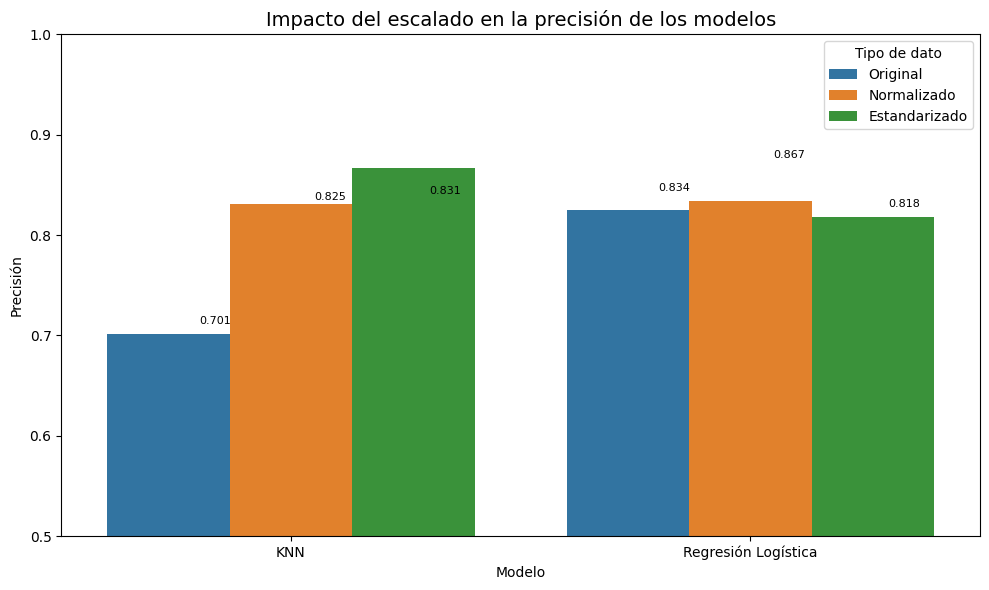

In [16]:
# Creamos un DataFrame para comparar las precisiones
# obtenidas por cada modelo con diferentes tipos de escalado
comparativa = pd.DataFrame({
    'Modelo': ['KNN', 'Regresión Logística'],
    
    # Resultados usando datos originales
    'Original': [
        resultados['Original'][0],
        resultados['Original'][1]
    ],
    
    # Resultados usando datos normalizados
    'Normalizado': [
        resultados['Normalizado'][0],
        resultados['Normalizado'][1]
    ],
    
    # Resultados usando datos estandarizados
    'Estandarizado': [
        resultados['Estandarizado'][0],
        resultados['Estandarizado'][1]
    ]
})

# Mostramos la tabla comparativa de precisiones
print("\n=== TABLA COMPARATIVA DE PRECISIONES ===")
print(comparativa)

# Convertimos el DataFrame a formato largo
# para facilitar la visualización con seaborn
comparativa_melt = comparativa.melt(
    id_vars='Modelo',
    var_name='Escalado',
    value_name='Precisión'
)

# Creamos una figura para el gráfico comparativo
plt.figure(figsize=(10, 6))

# Generamos gráfico de barras comparando precisiones
sns.barplot(
    data=comparativa_melt,
    x='Modelo',
    y='Precisión',
    hue='Escalado'
)

# Título del gráfico
plt.title('Impacto del escalado en la precisión de los modelos', fontsize=14)

# Definimos límites del eje Y
plt.ylim(0.5, 1.0)

# Etiqueta del eje Y
plt.ylabel('Precisión')

# Mostramos la leyenda
plt.legend(title='Tipo de dato')

# Agregamos los valores de precisión encima de cada barra
for i, (modelo, escala, precision) in enumerate(
    zip(
        comparativa_melt['Modelo'],
        comparativa_melt['Escalado'],
        comparativa_melt['Precisión']
    )
):
    plt.text(
        i//3 + (i%3)*0.25 - 0.2,
        precision + 0.01,
        f'{precision:.3f}',
        fontsize=8
    )

# Ajustamos automáticamente el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()

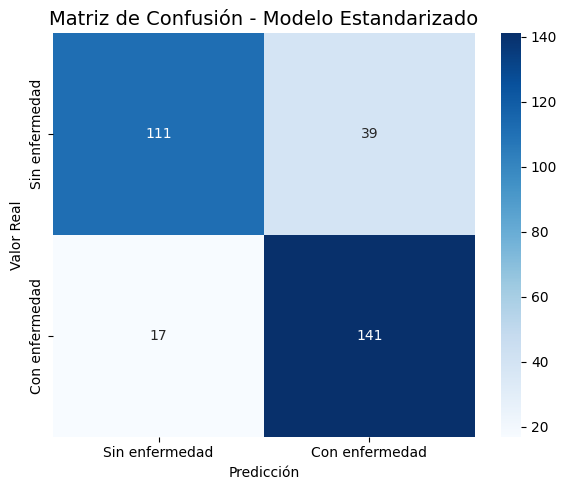


=== REPORTE DE CLASIFICACIÓN ===
                precision    recall  f1-score   support

Sin enfermedad       0.87      0.74      0.80       150
Con enfermedad       0.78      0.89      0.83       158

      accuracy                           0.82       308
     macro avg       0.83      0.82      0.82       308
  weighted avg       0.82      0.82      0.82       308



In [17]:
# Utilizamos el mejor modelo identificado:
# Regresión Logística con datos estandarizados
mejor_modelo = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento estandarizados
mejor_modelo.fit(X_train_std, y_train)

# Realizamos predicciones con los datos de prueba
y_pred_mejor = mejor_modelo.predict(X_test_std)

# ---------------- MATRIZ DE CONFUSIÓN ----------------
# Calculamos la matriz de confusión para evaluar el rendimiento
cm = confusion_matrix(y_test, y_pred_mejor)

# Creamos una figura para visualizar la matriz
plt.figure(figsize=(6, 5))

# Generamos mapa de calor de la matriz de confusión
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    
    # Etiquetas de las clases
    xticklabels=['Sin enfermedad', 'Con enfermedad'],
    yticklabels=['Sin enfermedad', 'Con enfermedad']
)

# Título del gráfico
plt.title('Matriz de Confusión - Modelo Estandarizado', fontsize=14)

# Etiquetas de los ejes
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

# Ajustamos automáticamente el diseño
plt.tight_layout()

# Mostramos el gráfico
plt.show()

# ---------------- REPORTE DE CLASIFICACIÓN ----------------
# Mostramos métricas de evaluación:
# precisión, recall, f1-score y soporte
print("\n=== REPORTE DE CLASIFICACIÓN ===")

print(
    classification_report(
        y_test,
        y_pred_mejor,
        target_names=['Sin enfermedad', 'Con enfermedad']
    )
)

## CONCLUSIONES DEL ANÁLISIS CLÍNICO

Las variables clínicas presentan diferentes escalas numéricas, lo que puede afectar el rendimiento de los modelos de Machine Learning, especialmente aquellos basados en distancias.

Por ejemplo:
- El colesterol posee valores mucho mayores que la edad o la presión arterial.
- Esto provoca que algunas variables tengan más influencia en el modelo debido únicamente a su magnitud numérica.

Se comparó el rendimiento de los modelos utilizando:
- Datos originales
- Datos normalizados
- Datos estandarizados

El modelo KNN mostró una mejora considerable después de aplicar técnicas de escalado, especialmente con estandarización.

La Regresión Logística también presentó mejoras en estabilidad y precisión tras el preprocesamiento de los datos.

Para aplicaciones médicas, se recomienda aplicar técnicas de normalización o estandarización antes de entrenar modelos predictivos.

Un modelo entrenado sin preprocesamiento adecuado podría generar:
- Diagnósticos incorrectos
- Falsos positivos o falsos negativos
- Mala interpretación de variables clínicas

En conclusión, el preprocesamiento de datos es un paso fundamental para mejorar la precisión, estabilidad y confiabilidad de modelos utilizados en diagnósticos médicos.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
import pickle
import os

In [19]:
# ========== DUMMY CLASSIFIER ==========
dummy = DummyClassifier(strategy='prior', random_state=42)
dummy.fit(X_train_std, y_train)
acc_dummy = dummy.score(X_test_std, y_test)
print(f"Dummy Accuracy: {acc_dummy:.4f}")

Dummy Accuracy: 0.5130


In [20]:
# ========== SVC ==========
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_std, y_train)
acc_svc = svc.score(X_test_std, y_test)
print(f"SVC Accuracy: {acc_svc:.4f}")

SVC Accuracy: 0.9058


In [21]:
# ========== GUARDAR MODELOS ==========
os.makedirs('models', exist_ok=True)


In [22]:
# Guardar SVC (mejor que Dummy)
with open('models/model_svc.pkl', 'wb') as f:
    pickle.dump(svc, f)

In [23]:
# Guardar el scaler que ya tienes
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(standardizer, f)

print("✅ Modelo SVC y Scaler guardados en carpeta 'models'")

✅ Modelo SVC y Scaler guardados en carpeta 'models'
